In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

X, y = make_moons(n_samples = 500, noise = 0.25, random_state = 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def plot_activation(func, name, x_range = (-5,5)):
  x = np.linspace(*x_range, 100)
  y = func(x)
  plt.figure(figsize = (5,4))
  plt.plot(x,y)
  plt.title(f"{name} Activation")
  plt.grid(True)
  plt.show()

In [ ]:
def train_and_plot(activation, act_name):
  model = MLPClassifier(hidden_layer_sizes = (8,), activation = activation, solver = 'adam',max_iter =1000, random_state = 42)
  model.fit(X_train , y_train)
  y_pred = model.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  h = .02
  xx, yy = np.meshgrid(np.arange(X_train[:, 0].min()-1, X_train[:, 0].max()+1, h),
                     np.arange(X_train[:, 1].min()-1, X_train[:, 1].max()+1, h))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.figure(figsize=(5,4))
  plt.contourf(xx, yy, Z, alpha=0.4)
  plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=20, edgecolor='k')
  plt.title(f"{act_name} - Accuracy: {acc:.2f}")
  plt.show()
  return acc





In [ ]:
def linear(x):
  return x

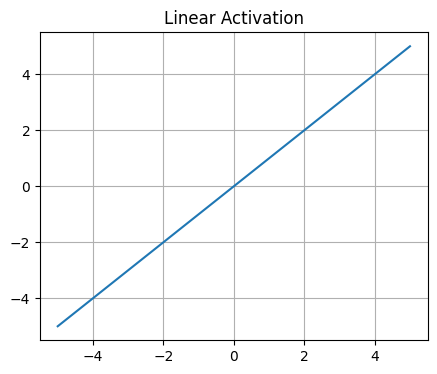

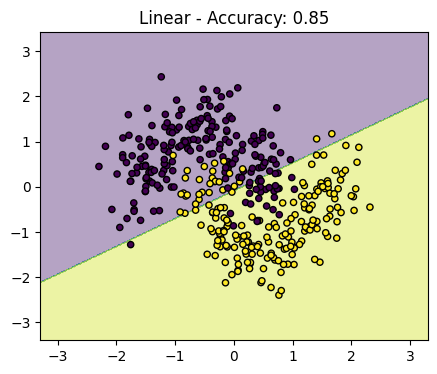

In [ ]:
results = {}
plot_activation(linear, "Linear")
results['Linear'] = train_and_plot('identity', 'Linear')

In [ ]:
def sigmoid(x):
  return 1/ (1 + np.exp(-x))

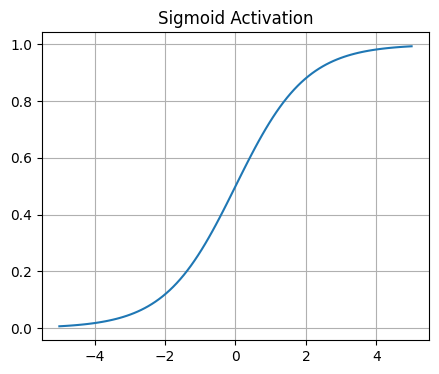

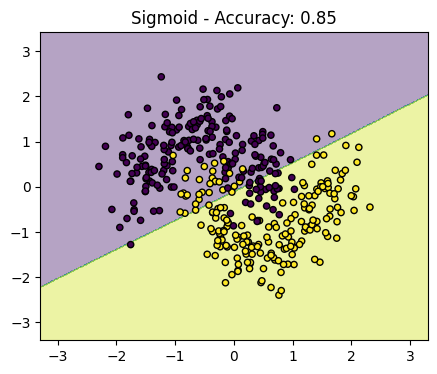

In [ ]:
results = {}
plot_activation(sigmoid, "Sigmoid")
results['Sigmoid'] = train_and_plot('logistic', 'Sigmoid')

In [ ]:
def tanh_fn(x):
  return np.tanh(x)

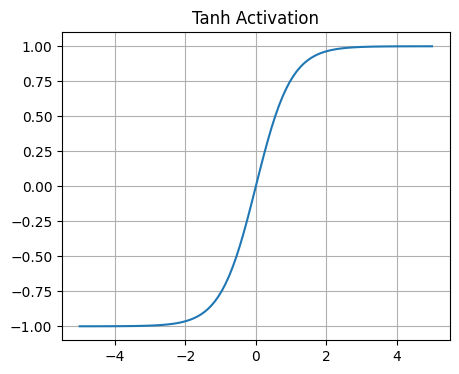

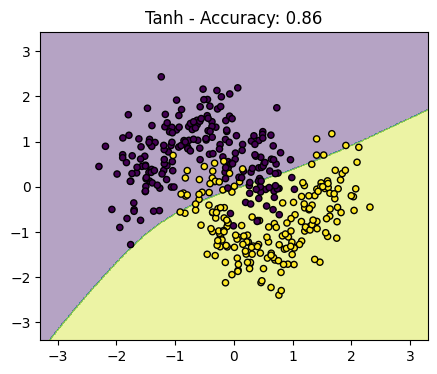

In [ ]:
results = {}
plot_activation(tanh_fn, "Tanh")
results["Tanh"] =  train_and_plot('tanh', 'Tanh')

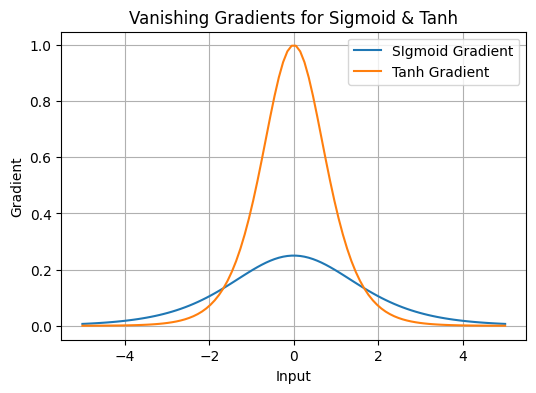

In [ ]:
x = np.linspace(-5,5,100)
grad_sigmoid = sigmoid(x) * (1- sigmoid(x))
grad_tanh = 1 - np.tanh(x)**2

plt.figure(figsize = (6,4))
plt.plot(x, grad_sigmoid, label = 'SIgmoid Gradient')
plt.plot(x, grad_tanh, label = 'Tanh Gradient')
plt.title("Vanishing Gradients for Sigmoid & Tanh")
plt.xlabel("Input")
plt.ylabel("Gradient")
plt.legend()
plt.grid(True)
plt.show()

**Relu Activation Function**

In [ ]:
def relu(x):
  return np.maximum(0,x)

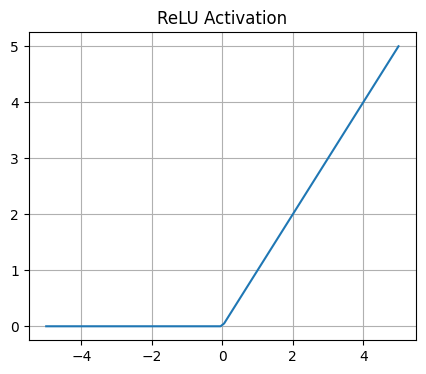

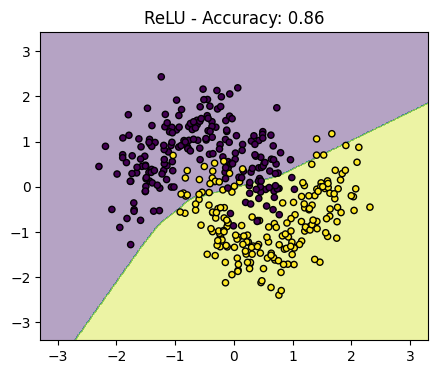

In [ ]:
results = {}
plot_activation(relu, "ReLU")
results["ReLU"] = train_and_plot('relu', 'ReLU')

**Dying ReLU Problem**

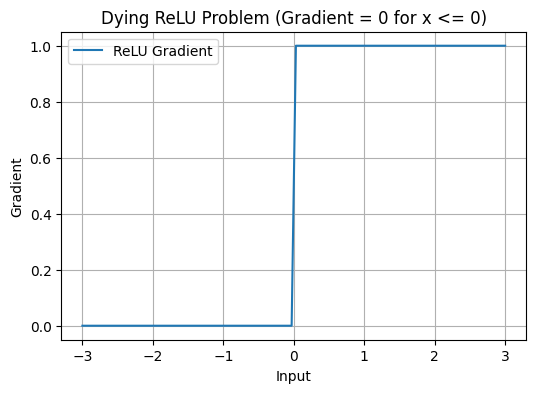

In [ ]:
np.random.seed(42)
x = np.linspace(-3,3,100)
relu_output = relu(x)
grad_relu = np.where(x > 0,1,0)
plt.figure(figsize = (6,4))
plt.plot(x, grad_relu, label = 'ReLU Gradient')
plt.title("Dying ReLU Problem (Gradient = 0 for x <= 0)")
plt.xlabel("Input")
plt.ylabel("Gradient")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
def leaky_relu(x, alpha = 0.1):
  return np.where(x > 0,x,alpha * x)

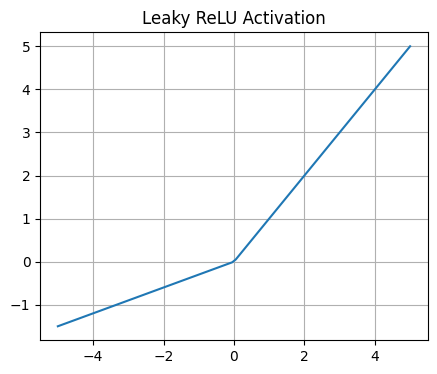

In [ ]:
plot_activation(lambda x: leaky_relu(x, alpha = 0.3), "Leaky ReLU")
results['Leaky ReLU'] = None

**Softmax**

In [ ]:
def softmax(x):
  e_x = np.exp(x - np.max(x))
  return e_x / e_x.sum(axis = 0)

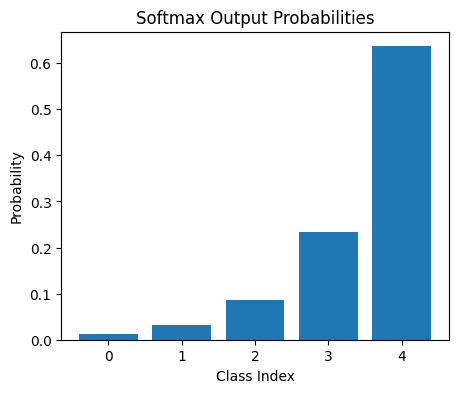

In [ ]:
x_vals = np.linspace(-2,2,5)
softmax_outputs = softmax(x_vals)
plt.figure(figsize = (5,4))
plt.bar(range(len(softmax_outputs)),softmax_outputs)
plt.title("Softmax Output Probabilities")
plt.xlabel("Class Index")
plt.ylabel("Probability")
plt.show()
results['SOftmax'] = None